In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 31.2 MB/s  0:00:00eta 0:00:01
Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl (5.4 MB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 31.2 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.7 MB/s  0:00:00
Using cached pillow-12.3.0-cp

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed so all students get the exact same random numbers
np.random.seed(42)

# 1. Create an array of 100 days (Day 1 to 100)
days = np.arange(1, 101)
print(days)

# 2. Simulate 100 days of Temperatures (Average 75 degrees, standard deviation of 10)
temperatures = np.random.normal(loc=75, scale=10, size=100)
temperatures = np.round(temperatures, 1) # Round to 1 decimal place

# 3. Simulate Sales (Ice cream goes up when it's hot, coffee goes down)
# Add a little random noise so the data doesn't look completely artificial
ice_cream_sales = (temperatures * 4) + np.random.normal(0, 20, 100)
coffee_sales = (400 - (temperatures * 3)) + np.random.normal(0, 15, 100)

# Clean up negative sales (can't sell less than 0 items)
ice_cream_sales = np.maximum(ice_cream_sales, 0)
coffee_sales = np.maximum(coffee_sales, 0)

print(f"First 5 temperatures: {temperatures[:5]}")
print(f"First 5 days of ice cream sales: {ice_cream_sales[:5]}")
print(f"First 5 days of coffee sales: {coffee_sales[:5]}")

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
First 5 temperatures: [80.  73.6 81.5 90.2 72.7]
First 5 days of ice cream sales: [291.69258516 285.98709354 319.14570967 344.75445462 287.57428577]
First 5 days of coffee sales: [165.36681041 187.6117679  171.74576865 145.20703078 161.23495948]


In [ ]:
# 1. Create the DataFrame to organize our arrays into columns
df = pd.DataFrame({
    'Day': days,
    'Temperature': temperatures,
    'Ice_Cream': np.round(ice_cream_sales),
    'Coffee': np.round(coffee_sales)
})

# 2. Basic Exploration 
# df.head()
# df.describe()

# 3. Feature Engineering: Create a new column for Total Items Sold
df['Total_Sales'] = df['Ice_Cream'] + df['Coffee']

# 4. Data Filtering: Let's analyze "Heatwave" days (over 85 degrees)
heatwave_df = df[df['Temperature'] > 85]

# Find the single day with the highest total sales
best_day = df[df['Total_Sales'] == df['Total_Sales'].max()]

print("Our Best Sales Day:")
print(best_day)

Our Best Sales Day:
    Day  Temperature  Ice_Cream  Coffee  Total_Sales
20   21         89.7      375.0   166.0        541.0


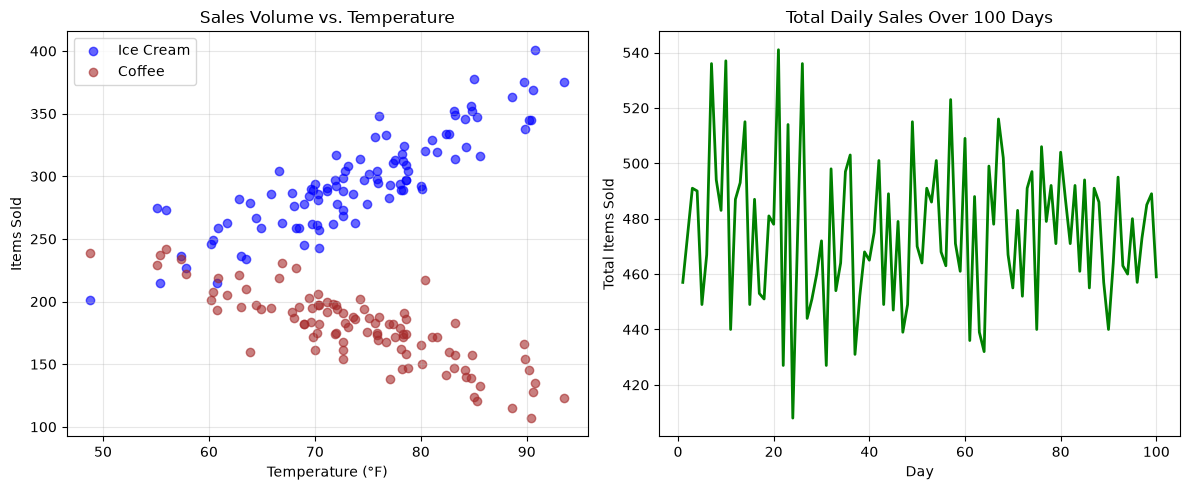

In [ ]:
# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Scatter Plot (Correlation) ---
# Does temperature really affect sales? Let's prove it visually.
ax1.scatter(df['Temperature'], df['Ice_Cream'], color='blue', alpha=0.6, label='Ice Cream')
ax1.scatter(df['Temperature'], df['Coffee'], color='brown', alpha=0.6, label='Coffee')
ax1.set_title('Sales Volume vs. Temperature')
ax1.set_xlabel('Temperature (°F)')
ax1.set_ylabel('Items Sold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Line Graph (Trends over Time) ---
# How did our total sales look over the 100 days?
ax2.plot(df['Day'], df['Total_Sales'], color='green', linewidth=2)
ax2.set_title('Total Daily Sales Over 100 Days')
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Items Sold')
ax2.grid(True, alpha=0.3)

# Display the graphs cleanly
plt.tight_layout()
plt.show()

In [ ]:
lemonade_sales = temperature * 5 + np.random.normal(0, 10, 100)
df["Lemonade"] = lemonade_sales
df["Total_Sales"] = df["Total_Sales"] + df["Lemonade"]
plt.figure(figsize=(10, 6))

plt.plot(df["Ice_Cream"], label="Ice Cream")
plt.plot(df["Coffee"], label="Coffee")
plt.plot(df["Lemonade"], label="Lemonade")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales Over 100 Days")
plt.legend()

plt.show()